In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import CoxPHFitter
from lifelines.plotting import plot_lifetimes
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [41]:
df=pd.read_excel("relapse_alcohol.xlsx")


In [42]:
df.head(10)

,Date,Sr. No.,Registration Number,Sex,Age,Marital Status,Diagnosis,Qualification,Employment Status,Annual Income,exit_date,relapse,readmission_date
0,2021-08-04,1,23087,M,29,NM,Alcohol,Middle School,U.E.,60000.0,2021-09-03,No,NaT
1,2021-08-04,3,23095,M,43,M,Alcohol,H.S.C.,U.E.,45000.0,2021-09-03,No,NaT
2,2021-08-04,4,N-304,M,34,M,Alcohol,H.S.C.,U.E.,180000.0,2021-09-03,Yes,2022-05-13
3,2021-08-11,5,23118,M,42,M,Alcohol,H.S.C.,S.E.,50000.0,2021-09-10,No,NaT
4,2021-08-11,6,2345,M,74,M,Alcohol,Middle School,Pensioner,50000.0,2021-09-10,Yes,2022-04-13
5,2021-08-18,11,22818,M,33,M,Alcohol,Middle School,S.E.,150000.0,2021-09-17,No,NaT
6,2021-08-18,12,23156,M,37,M,Alcohol,Middle School,S.E.,80000.0,2021-09-17,Yes,2022-05-09
7,2021-08-18,13,23010,M,30,M,Alcohol,Middle School,S.E.,60000.0,2021-09-17,No,NaT
8,2021-08-25,14,23165,M,38,M,Alcohol,Middle School,S.E.,35000.0,2021-09-24,Yes,2022-06-01
9,2021-08-25,15,23174,M,48,M,Alcohol,Graduate,S.E.,65000.0,2021-09-24,Yes,2022-02-24


In [43]:
df.columns

Index(['Date', 'Sr. No.', 'Registration Number', 'Sex', 'Age',
       'Marital Status', 'Diagnosis', 'Qualification', 'Employment Status',
       'Annual Income', 'exit_date', 'relapse', 'readmission_date'],
      dtype='object')

In [44]:
df.shape

(322, 13)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 322 non-null    datetime64[ns]
 1   Sr. No.              322 non-null    int64         
 2   Registration Number  322 non-null    object        
 3   Sex                  322 non-null    object        
 4   Age                  322 non-null    int64         
 5   Marital Status       322 non-null    object        
 6   Diagnosis            322 non-null    object        
 7   Qualification        322 non-null    object        
 8   Employment Status    322 non-null    object        
 9   Annual Income        254 non-null    float64       
 10  exit_date            322 non-null    datetime64[ns]
 11  relapse              322 non-null    object        
 12  readmission_date     244 non-null    datetime64[ns]
dtypes: datetime64[ns](3), float64(1), i

In [46]:
df.isnull().sum()

Date                    0
Sr. No.                 0
Registration Number     0
Sex                     0
Age                     0
Marital Status          0
Diagnosis               0
Qualification           0
Employment Status       0
Annual Income          68
exit_date               0
relapse                 0
readmission_date       78
dtype: int64

In [47]:
# Summary statistics
df.describe()

,Date,Sr. No.,Age,Annual Income,exit_date,readmission_date
count,322,322.000000,322.000000,254.000000,322,244
mean,2022-04-21 10:08:11.925465856,200.385093,38.422360,70569.685039,2022-05-21 10:08:11.925465856,2023-02-17 15:50:09.836065536
min,2021-08-04 00:00:00,1.000000,16.000000,14000.000000,2021-09-03 00:00:00,2022-01-17 00:00:00
25%,2021-11-12 12:00:00,99.750000,32.000000,44000.000000,2021-12-12 12:00:00,2022-08-20 18:00:00
50%,2022-03-02 00:00:00,201.500000,38.000000,50000.000000,2022-04-01 00:00:00,2023-01-08 00:00:00
75%,2022-09-21 00:00:00,300.750000,44.000000,80000.000000,2022-10-21 00:00:00,2023-08-15 12:00:00
max,2023-03-31 00:00:00,398.000000,74.000000,600000.000000,2023-04-30 00:00:00,2024-08-31 00:00:00
std,NaN,114.551846,9.506279,64519.318937,NaN,NaN


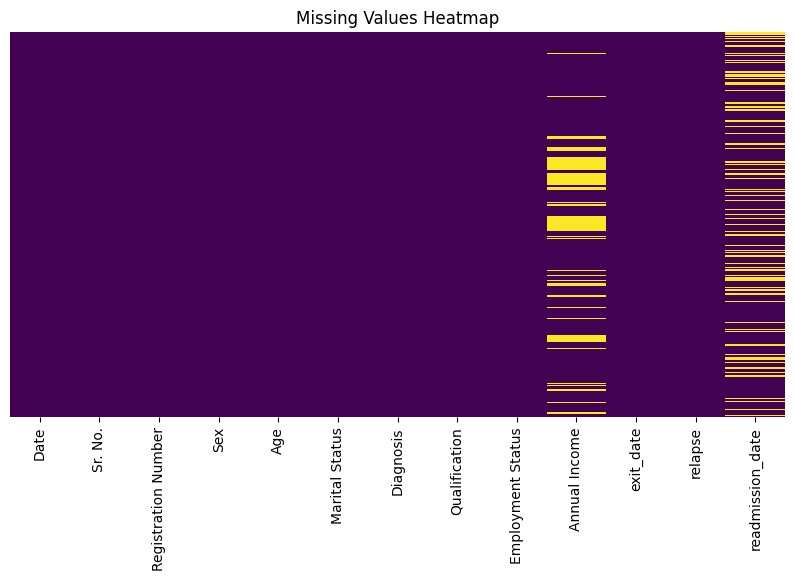

In [48]:
# Missing Values Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cmap="viridis", cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

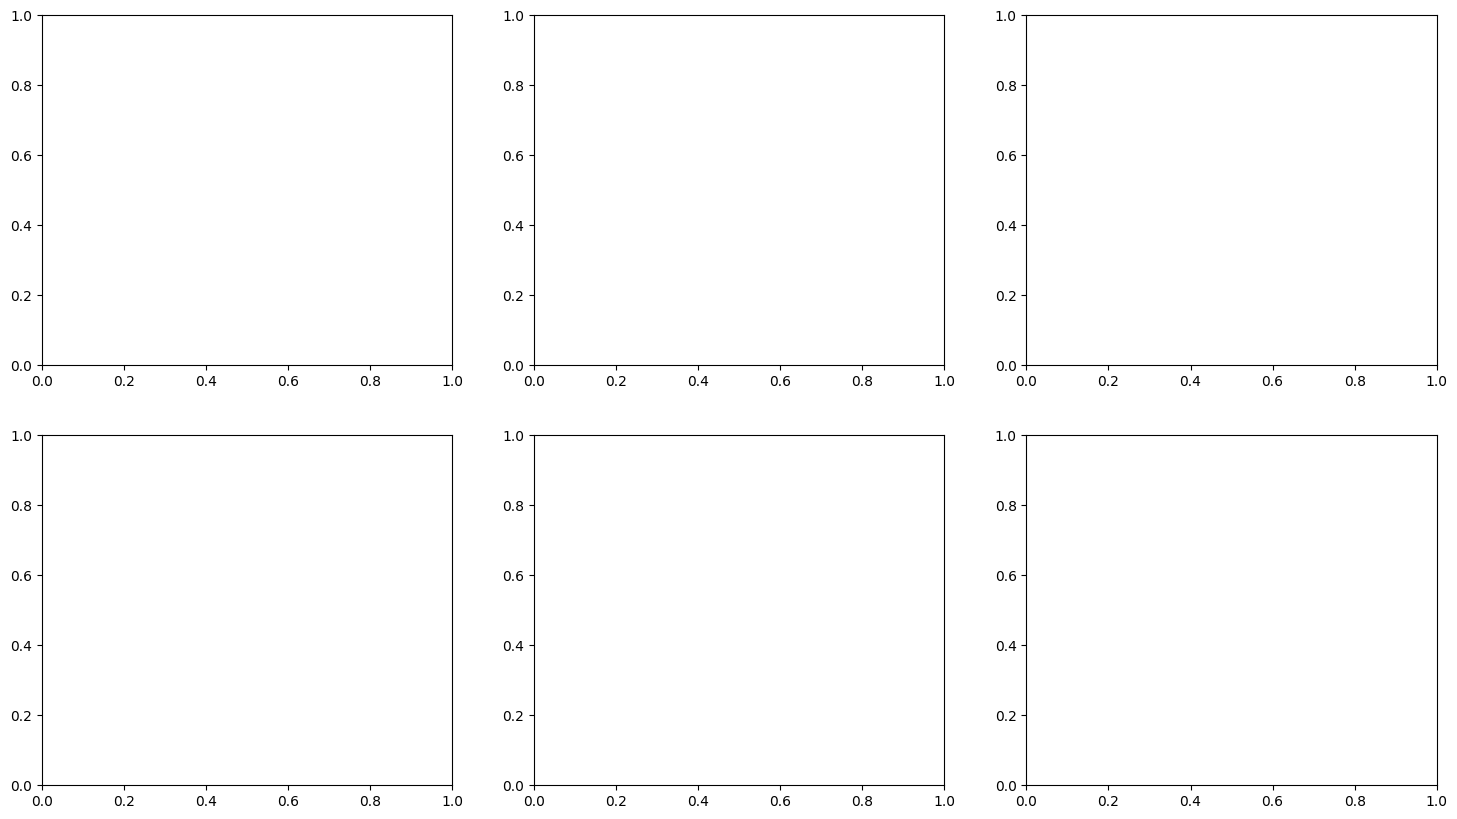

In [49]:
# Categorical Data Visualization
categorical_cols = ["Sex", "Marital Status", "Qualification", "Employment Status", "relapse"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()


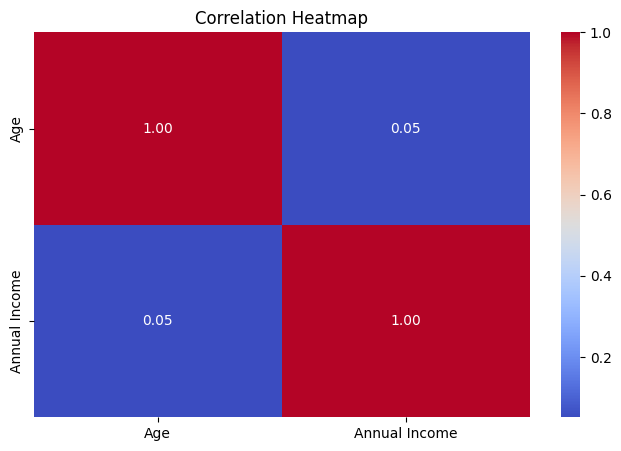

In [50]:
# Correlation Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df[["Age", "Annual Income"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

C:\Users\Saurav Ghadshi\AppData\Local\Temp\ipykernel_9880\4103663139.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'])


<Axes: xlabel='Age', ylabel='Density'>

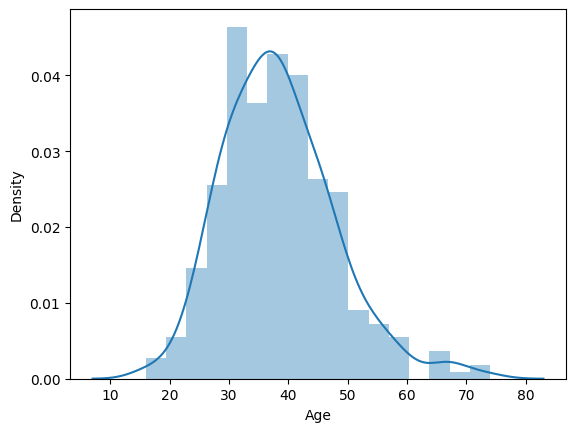

In [51]:
 #b.displot
sns.distplot(df['Age'])

In [52]:

sns.boxplot(data=df, x="relapse", y="Annual Income", ax=axes[1])
axes[1].set_title("Annual Income Distribution by Relapse Status")

Text(0.5, 1.0, 'Annual Income Distribution by Relapse Status')

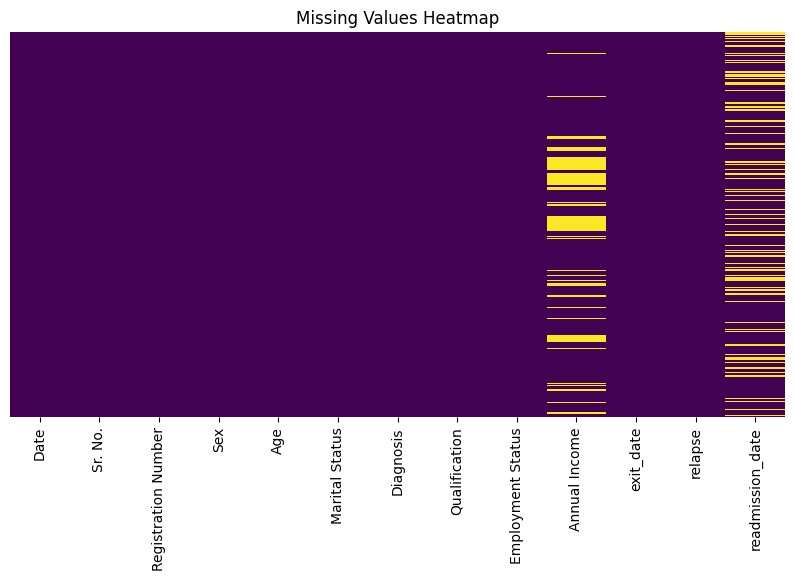

(Date                    0
 Sr. No.                 0
 Registration Number     0
 Sex                     0
 Age                     0
 Marital Status          0
 Diagnosis               0
 Qualification           0
 Employment Status       0
 Annual Income          68
 exit_date               0
 relapse                 0
 readmission_date       78
 dtype: int64,
                                 Date     Sr. No.         Age  Annual Income  \
 count                            322  322.000000  322.000000     254.000000   
 mean   2022-04-21 10:08:11.925465856  200.385093   38.422360   70569.685039   
 min              2021-08-04 00:00:00    1.000000   16.000000   14000.000000   
 25%              2021-11-12 12:00:00   99.750000   32.000000   44000.000000   
 50%              2022-03-02 00:00:00  201.500000   38.000000   50000.000000   
 75%              2022-09-21 00:00:00  300.750000   44.000000   80000.000000   
 max              2023-03-31 00:00:00  398.000000   74.000000  600000.0000

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check missing values
missing_values = df.isnull().sum()

# Summary statistics for numerical columns
summary_stats = df.describe()

# Plot missing values heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cmap="viridis", cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

missing_values, summary_stats


C:\Users\Saurav Ghadshi\AppData\Local\Temp\ipykernel_9880\3835509978.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette="viridis")
C:\Users\Saurav Ghadshi\AppData\Local\Temp\ipykernel_9880\3835509978.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
C:\Users\Saurav Ghadshi\AppData\Local\Temp\ipykernel_9880\3835509978.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette="viridis")
C:\Users\Saurav Ghadshi\AppData\Local\Temp\ipykernel_9880\3835509978.py:9: UserWarning: s


Key Insights for Sex:
Sex
M    322
Name: count, dtype: int64

Key Insights for Marital Status:
Marital Status
M      243
NM      61
SEP     11
D        5
UM       1
W        1
Name: count, dtype: int64

Key Insights for Qualification:
Qualification
Middle School    123
H.S.C.           102
Graduate          66
P.T.              27
Masters            4
Name: count, dtype: int64

Key Insights for Employment Status:
Employment Status
S.E.         124
U.E.         113
Employed      62
N.E.           8
Part Time      7
Student        5
Pensioner      3
Name: count, dtype: int64


C:\Users\Saurav Ghadshi\AppData\Local\Temp\ipykernel_9880\3835509978.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette="viridis")
C:\Users\Saurav Ghadshi\AppData\Local\Temp\ipykernel_9880\3835509978.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)



Key Insights for relapse:
relapse
Yes    244
No      78
Name: count, dtype: int64


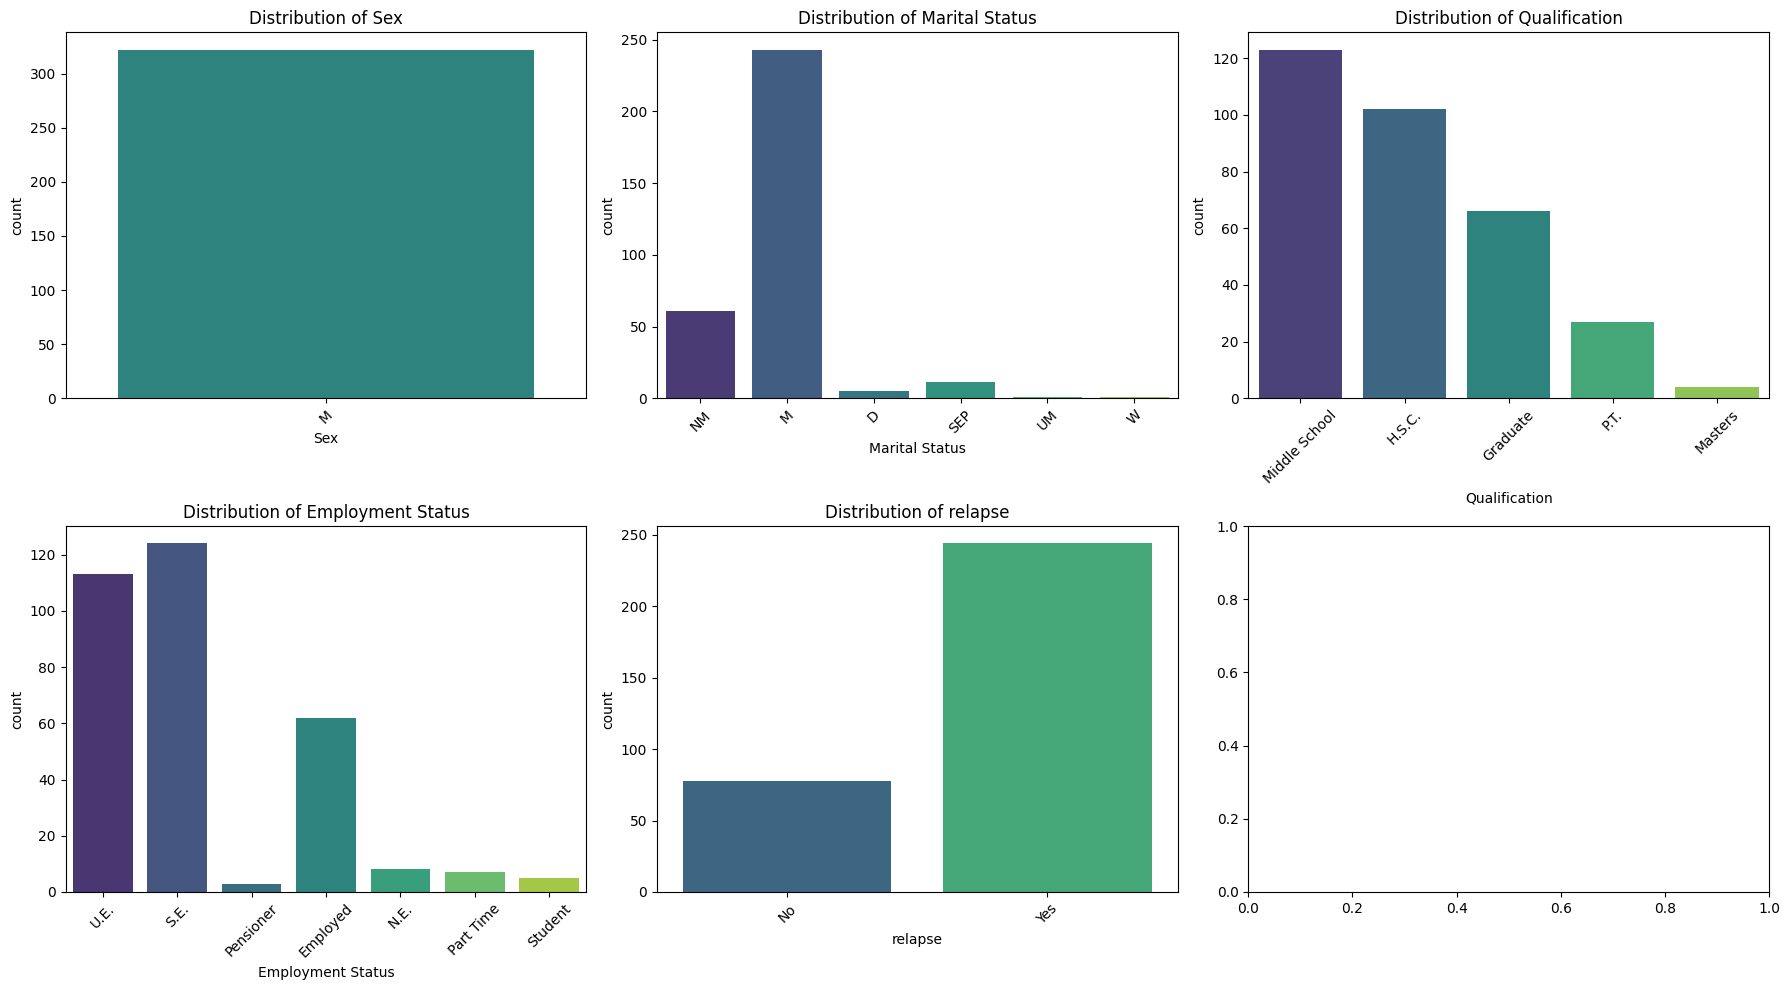

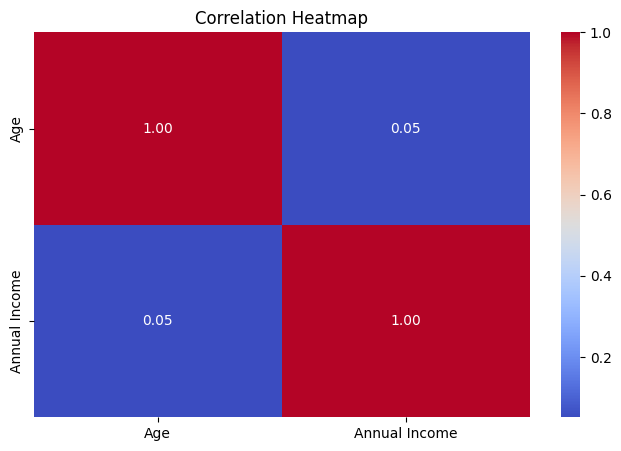

C:\Users\Saurav Ghadshi\AppData\Local\Temp\ipykernel_9880\3835509978.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="relapse", y="Age", ax=axes[0], palette="magma")
C:\Users\Saurav Ghadshi\AppData\Local\Temp\ipykernel_9880\3835509978.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="relapse", y="Annual Income", ax=axes[1], palette="magma")


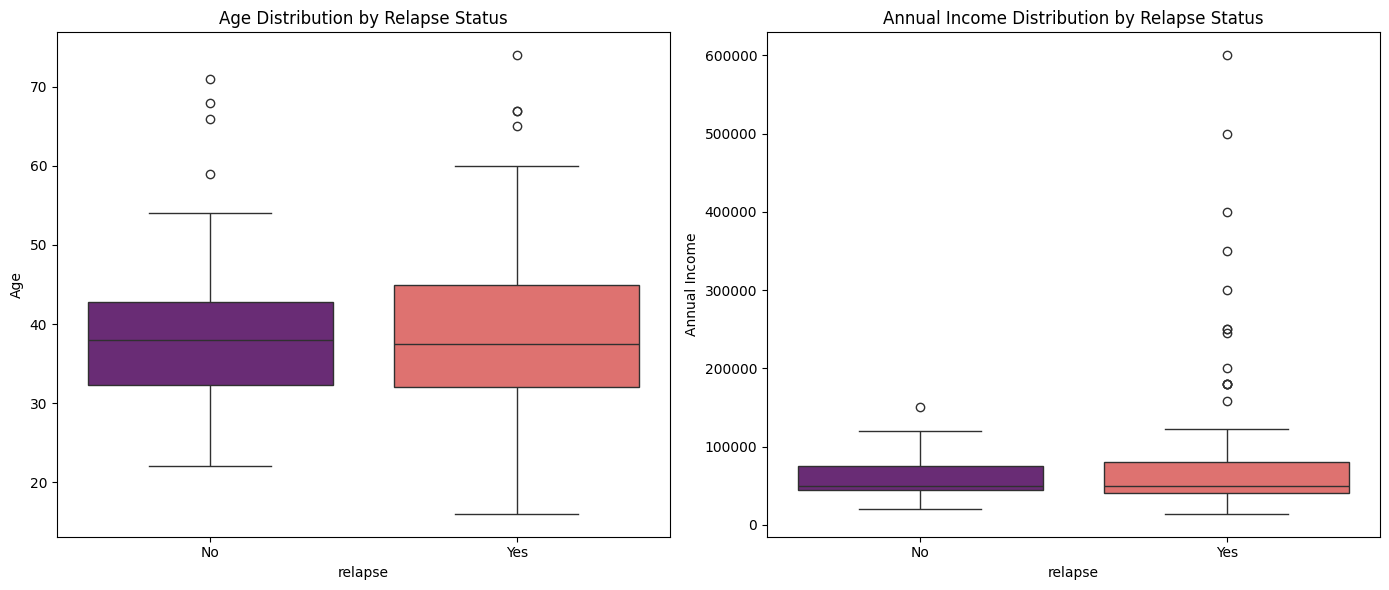

In [54]:
# Categorical Data Visualization

categorical_cols = ["Sex", "Marital Status", "Qualification", "Employment Status", "relapse"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette="viridis")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
    axes[i].set_title(f"Distribution of {col}")
    
    # Print key insights
    print(f"\nKey Insights for {col}:")
    print(df[col].value_counts())

plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df[["Age", "Annual Income"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Boxplots for Relapse Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x="relapse", y="Age", ax=axes[0], palette="magma")
axes[0].set_title("Age Distribution by Relapse Status")

sns.boxplot(data=df, x="relapse", y="Annual Income", ax=axes[1], palette="magma")
axes[1].set_title("Annual Income Distribution by Relapse Status")

plt.tight_layout()
plt.show()


In [55]:
#Gender: Majority of patients are male.
#Marital Status: More patients are married than unmarried.
#Qualification: Education levels vary, but many have middle school or H.S.C..
#Employment: A significant number are unemployed.
#Relapse: There is a considerable proportion of relapse cases




In [56]:
#!pip install pandas-profiling

In [57]:
#!pip install --upgrade pandas-profiling
#!pip install numba==0.53.1

In [58]:
#from pandas_profiling import ProfileReport
#prof=ProfileReport(df)
#prof.to_file(output_file='output.html')

In [59]:
#Correlation Analysis:
#Weak correlation between age and income (not strongly linked).
#Relapse Patterns:
#Age: No significant difference between relapsed and non-relapsed groups.
#Annual Income: Relapsed individuals tend to have a slightly lower income on average.

In [60]:
df['relapse'].unique()

array(['No', 'Yes'], dtype=object)

In [61]:

duplicates = df[df.duplicated(subset='Registration Number', keep=False)]

# 2. One-Hot Encoding for 'Marital Status' and 'Relapse'
df_one_hot = pd.get_dummies(df, columns=['Marital Status', 'relapse'])

# 3. Split 'Date' into Year, Month, Day columns
df_one_hot['Date'] = pd.to_datetime(df_one_hot['Date'])
df_one_hot['Year'] = df_one_hot['Date'].dt.year
df_one_hot['Month'] = df_one_hot['Date'].dt.month
df_one_hot['Day'] = df_one_hot['Date'].dt.day

# 4. Ordinal Ranking for 'Qualification' column
education_order = {
    'Middle School': 1,
    'H.S.C.': 2,
    'Graduate':3,
    'Maseters':4,
    'P.T':5
}

df_one_hot['Qualification_Rank'] = df_one_hot['Qualification'].map(education_order)

# Show the results
df_one_hot, duplicates

(          Date  Sr. No. Registration Number Sex  Age Diagnosis  Qualification  \
 0   2021-08-04        1               23087   M   29   Alcohol  Middle School   
 1   2021-08-04        3               23095   M   43   Alcohol         H.S.C.   
 2   2021-08-04        4               N-304   M   34   Alcohol         H.S.C.   
 3   2021-08-11        5               23118   M   42   Alcohol         H.S.C.   
 4   2021-08-11        6                2345   M   74   Alcohol  Middle School   
 ..         ...      ...                 ...  ..  ...       ...            ...   
 317 2023-03-31      393               22161   M   35   Alcohol  Middle School   
 318 2023-03-31      394               23059   M   46   Alcohol  Middle School   
 319 2023-03-31      396               23074   M   38   Alcohol  Middle School   
 320 2023-03-31      397               23075   M   29   Alcohol  Middle School   
 321 2023-03-31      398               16806   M   44   Alcohol         H.S.C.   
 
     Employmen

In [62]:
# 1. Check for duplicates in 'Registration Number'
duplicates = df[df.duplicated(subset='Registration Number', keep=False)]

# 2. One-Hot Encoding for 'Marital Status' and 'Relapse' columns
# Marital Status Mapping
marital_status_mapping = {
    'M': 1,  # Married
    'NM': 0, # Not Married
    'D': 0,  # Divorced
    'SEP': 0, # Separated
    'UM': 0, # Unmarried
    'W': 0   # Widowed
}

# Relapse Mapping
relapse_mapping = {
    'Yes': 1,  # Relapsed
    'No': 0    # Not Relapsed
}

df['Marital Status'] = df['Marital Status'].map(marital_status_mapping)
df['relapse'] = df['relapse'].map(relapse_mapping)

# 3. Split 'Date' into Year, Month, Day columns
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

# 4. Ordinal Ranking for 'Qualification' column
education_order = {
    'Middle School': 1,
    'H.S.C.': 2,
    'Graduate': 3,
    'Masters': 4,
    'P.T': 5
}

df['Qualification'] = df['Qualification'].map(education_order)

# Show the updated data and duplicates
df, duplicates

(          Date  Sr. No. Registration Number Sex  Age  Marital Status  \
 0   2021-08-04        1               23087   M   29               0   
 1   2021-08-04        3               23095   M   43               1   
 2   2021-08-04        4               N-304   M   34               1   
 3   2021-08-11        5               23118   M   42               1   
 4   2021-08-11        6                2345   M   74               1   
 ..         ...      ...                 ...  ..  ...             ...   
 317 2023-03-31      393               22161   M   35               1   
 318 2023-03-31      394               23059   M   46               1   
 319 2023-03-31      396               23074   M   38               1   
 320 2023-03-31      397               23075   M   29               1   
 321 2023-03-31      398               16806   M   44               1   
 
     Diagnosis  Qualification Employment Status  Annual Income  exit_date  \
 0     Alcohol            1.0              U.

In [63]:

# Convert 'exit_date' and 'readmission_date' to datetime
df['exit_date'] = pd.to_datetime(df['exit_date'], errors='coerce')
df['readmission_date'] = pd.to_datetime(df['readmission_date'], errors='coerce')

# Calculate relapse time (difference between exit_date and readmission_date)
df['relapse_time'] = (df['readmission_date'] - df['exit_date']).dt.days

# Calculate the mean and variance of relapse time (ignoring NaN values)
mean_relapse_time = df['relapse_time'].mean()
variance_relapse_time = df['relapse_time'].var()

mean_relapse_time, variance_relapse_time

(np.float64(263.8975409836066), np.float64(8194.191105039465))

In [64]:
# Ensure the categorical variables are in the correct format
df["Sex"] = df["Sex"].astype(str)  # Ensure "Sex" is a string (categorical variable)
df["relapse"] = df["relapse"].astype(int)  # Ensure "relapse" is binary (0 or 1)

# Create a contingency table for Fisher's Exact Test
contingency_table = pd.crosstab(df["Sex"], df["relapse"])

# Import the necessary method from scipy
import scipy.stats as stats

# Compute the Odds Ratio and P-value using Fisher's Exact Test
odds_ratio, p_value = stats.fisher_exact(contingency_table)

# Print the results
print("Odds Ratio:", odds_ratio)
print("P-value:", p_value)


Odds Ratio: 1.0
P-value: 1.0


## Cox Proportion Hazard Model

In [79]:
import pandas as pd
from lifelines import CoxPHFitter

# Load the dataset
df = pd.read_excel("relapse_alcohol.xlsx")  # Adjust path if needed

# Clean column names (remove spaces)
df.columns = df.columns.str.strip()

# Convert date columns
df["exit_date"] = pd.to_datetime(df["exit_date"], errors="coerce")
df["readmission_date"] = pd.to_datetime(df["readmission_date"], errors="coerce")

# Calculate relapse_time (days between exit and readmission)
df["relapse_time"] = (df["readmission_date"] - df["exit_date"]).dt.days

# Ensure relapse_time is positive
df = df[df["relapse_time"] > 0]

# Map relapse to binary (Yes = 1, No = 0)
df["relapse"] = df["relapse"].map({"Yes": 1, "No": 0})

# Fill missing relapse values with 0 (assuming no relapse)
df["relapse"].fillna(0, inplace=True)

# Ensure at least one event (relapse = 1) exists
if df["relapse"].sum() == 0:
    raise ValueError("No relapse events found. Cox regression requires at least one event (relapse = 1).")

# Select categorical columns for encoding
expected_columns = ["Sex", "Diagnosis", "Employment Status"]
existing_columns = [col for col in expected_columns if col in df.columns]

# Apply one-hot encoding to categorical variables
df = pd.get_dummies(df, columns=existing_columns, drop_first=True)

# Define independent variables
selected_vars = ["Age", "Annual Income"] + [col for col in df.columns if any(col.startswith(c) for c in existing_columns)]

# Drop NaNs & ensure dataset is not empty
df = df[selected_vars + ["relapse_time", "relapse"]].dropna()

if df.empty:
    raise ValueError("Dataset is empty after preprocessing. Check missing values and ensure valid input data.")

# Cox Regression Model
cph = CoxPHFitter()
cph.fit(df, duration_col="relapse_time", event_col="relapse")

# Print model summary
cph.print_summary()


C:\Users\Saurav Ghadshi\AppData\Local\Temp\ipykernel_9880\3044161721.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["relapse"].fillna(0, inplace=True)


<lifelines.CoxPHFitter: fitted with 189 total observations, 0 right-censored observations>
             duration col = 'relapse_time'
                event col = 'relapse'
      baseline estimation = breslow
   number of observations = 189
number of events observed = 189
   partial log-likelihood = -801.54
         time fit was run = 2025-03-14 11:13:30 UTC

---
                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                    
Age                          0.00      1.00      0.01           -0.02            0.02                0.98                1.02
Annual Income               -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Employment Status_N.E.      -0.62      0.54      0.54           -1.67            0.43                0.19                1.53
Employment Status_Part Time  0.30      1.35      0.53           -0.75            1.35                0.47                3.85
Employment Status_Pensioner  0.59      1.80      0.78           -0.93            2.11                0.39                8.24
Employment Status_S.E.      -0.46      0.63      0.21           -0.88           -0.04                0.41                0.96
Employment Status_Student   -0.35      0.70      0.63           -1.59            0.88                0.20                2.41
Employment Status_U.E.      -0.35      0.71      0.22           -0.78            0.09                0.46                1.09

                             cmp to     z    p  -log2(p)
covariate                                               
Age                            0.00  0.17 0.86      0.22
Annual Income                  0.00 -0.23 0.82      0.29
Employment Status_N.E.         0.00 -1.16 0.25      2.03
Employment Status_Part Time    0.00  0.56 0.58      0.79
Employment Status_Pensioner    0.00  0.76 0.45      1.16
Employment Status_S.E.         0.00 -2.16 0.03      5.02
Employment Status_Student      0.00 -0.56 0.57      0.80
Employment Status_U.E.         0.00 -1.57 0.12      3.10
---
Concordance = 0.56
Partial AIC = 1619.08
log-likelihood ratio test = 7.38 on 8 df
-log2(p) of ll-ratio test = 1.01

### Assumptions of checking Cox Regression


🔹 Checking Proportional Hazards Assumption...



<lifelines.StatisticalResult: proportional_hazard_test>
    time_transform = rank
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 189 total observations, 0 right-censored observations>
         test_name = proportional_hazard_test

---
               test_statistic    p  -log2(p)
Age                      0.14 0.70      0.51
Annual Income            0.28 0.60      0.75


🔹 Checking for Multicollinearity...



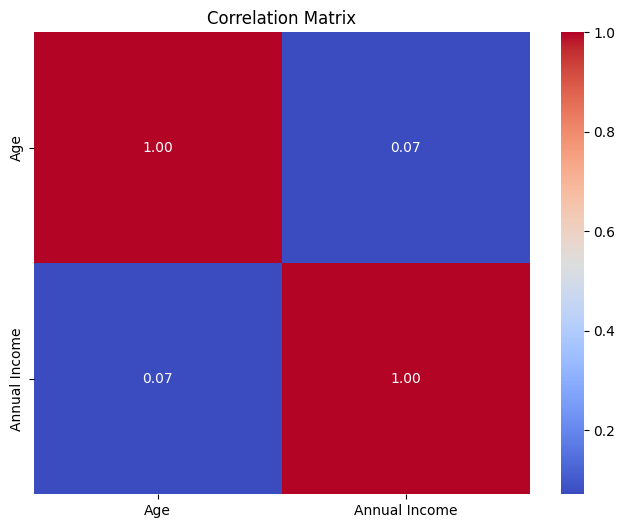

Variance Inflation Factor (VIF) Scores:
         Variable       VIF
0            Age  1.989239
1  Annual Income  1.989239

🔹 Checking Linearity of Continuous Variables...



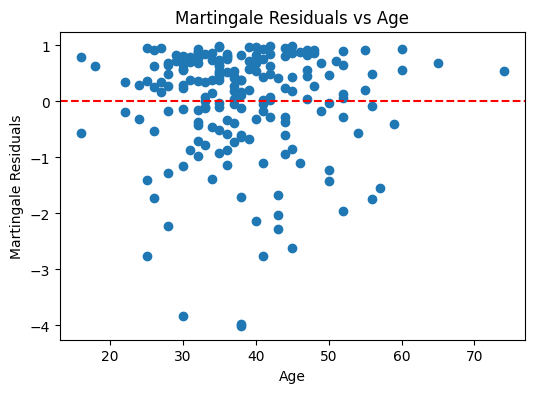

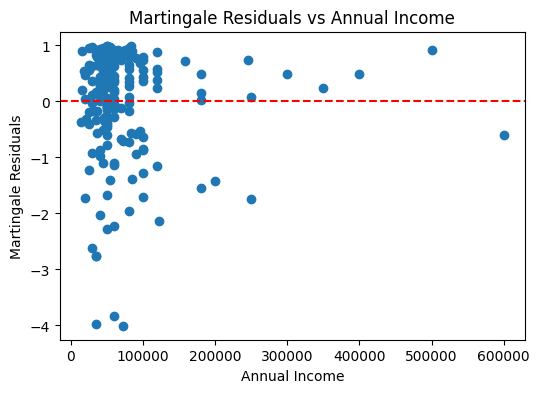


✅ Assumption Checks Completed!
1️⃣ Proportional Hazards: Check p-values in Schoenfeld Residuals test.
2️⃣ Multicollinearity: Check correlation & VIF scores.
3️⃣ Linearity: Check scatter plots of Martingale residuals.


In [82]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load Data (Ensure df is already prepared)
selected_vars = ["Age", "Annual Income"]  # Independent Variables
time_col = "relapse_time"
event_col = "relapse"

# Drop NaNs and Infinite Values
df = df[selected_vars + [time_col, event_col]].dropna()

# Fit Cox Regression Model
cph = CoxPHFitter()
cph.fit(df, duration_col=time_col, event_col=event_col)

# ------------------------------------------------------------
# 📌 1. CHECK PROPORTIONAL HAZARDS ASSUMPTION (Schoenfeld Residuals)
# ------------------------------------------------------------
print("\n🔹 Checking Proportional Hazards Assumption...\n")
ph_results = proportional_hazard_test(cph, df, time_transform="rank")
ph_results.print_summary()

# Interpretation: If p-value < 0.05, assumption is violated.

# ------------------------------------------------------------
# 📌 2. CHECK MULTICOLLINEARITY (Correlation & VIF)
# ------------------------------------------------------------
print("\n🔹 Checking for Multicollinearity...\n")

# Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df[selected_vars].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Variance Inflation Factor (VIF)
vif_data = pd.DataFrame()
vif_data["Variable"] = selected_vars
vif_data["VIF"] = [variance_inflation_factor(df[selected_vars].values, i) for i in range(len(selected_vars))]

print("Variance Inflation Factor (VIF) Scores:\n", vif_data)

# Interpretation: VIF > 5 indicates multicollinearity problem.

# ------------------------------------------------------------
# 📌 3. CHECK LINEARITY (Martingale Residuals)
# ------------------------------------------------------------
print("\n🔹 Checking Linearity of Continuous Variables...\n")

df["martingale_resid"] = cph.compute_residuals(df,kind="martingale")["martingale"]

for var in selected_vars:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[var], df["martingale_resid"])
    plt.axhline(y=0, color="red", linestyle="--")
    plt.xlabel(var)
    plt.ylabel("Martingale Residuals")
    plt.title(f"Martingale Residuals vs {var}")
    plt.show()

# Interpretation: If the plot shows a clear pattern, transformation (log, polynomial) may be needed.

# ------------------------------------------------------------
# 📌 SUMMARY OF ASSUMPTION CHECKS
# ------------------------------------------------------------
print("\n✅ Assumption Checks Completed!")
print("1️⃣ Proportional Hazards: Check p-values in Schoenfeld Residuals test.")
print("2️⃣ Multicollinearity: Check correlation & VIF scores.")
print("3️⃣ Linearity: Check scatter plots of Martingale residuals.")

